In [1]:
!pip install -q tf_keras_vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.3 MB/s eta 0:00:00


> ResSplit-KAN: A Self-Explainable Kolmogorov–Arnold Network–Integrated Custom Residual Split Multi-Scale Lightweight Model for Acute Lymphoblastic Leukemia Classification

In [2]:
# === System & OS Utilities ===
import os
import sys
import math
import pickle
import random
import warnings
warnings.filterwarnings("ignore")

# === Progress Bar ===
from tqdm import tqdm

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras import Model, Input, layers, initializers
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adamax, AdamW
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D, Dense, Dropout, Flatten, Layer,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    MaxPooling2D, BatchNormalization, ReLU,
    Add, Reshape, Multiply, Activation, Concatenate
)
from tensorflow.keras.utils import register_keras_serializable, plot_model

# === Data Handling ===
import numpy as np
import pandas as pd
import cv2

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# === Scikit-learn ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

import matplotlib
import sklearn

2025-11-27 11:16:20.842394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764242181.017242      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764242181.072388      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow version: 2.18.0
Keras version: 3.8.0
NumPy version: 1.26.4
Pandas version: 2.2.3
OpenCV version: 4.12.0
Matplotlib version: 3.7.2
Seaborn version: 0.12.2
Scikit-learn version: 1.2.2


In [4]:
#python version 3.11.11
#!python -m pip install tensorflow==2.18.0 keras==3.5.0 numpy==1.26.4 pandas==2.2.3 opencv-python==4.6.0.66 matplotlib==3.7.5 seaborn==0.12.2 scikit-learn==1.2.2

In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected: {len(gpus)}")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPUs detected.")

GPUs detected: 1


In [6]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCH = 30
img_shape=(*IMG_SIZE,3)
dataset_path = r"/kaggle/input/pbs-3242-normalized-resized-aug-8k-datasets/PBS-3242-Normalized-datasets/H_Separated_Dataset"
labels = sorted([d for d in os.listdir(dataset_path) 
                 if os.path.isdir(os.path.join(dataset_path, d))])
print("Class Names:", labels)

Class Names: ['Benign', 'Early Pre-B', 'Pre-B', 'Pro-B']


In [7]:
def data_frame(path):
    class_paths = []
    classes = []

    for label in os.listdir(path):
        class_dir = os.path.join(path, label)
        if os.path.isdir(class_dir):  
            for image in os.listdir(class_dir):
                class_paths.append(os.path.join(class_dir, image))
                classes.append(label)

    df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return df

In [8]:
dataframe = data_frame(dataset_path)
# First split: 70% train, 30% temp (val + test)
train_dataframe, temp_dataframe = train_test_split(
    dataframe,
    test_size=0.3,
    random_state=42,
    stratify=dataframe['Class']
)

# Second split: 2/3 val, 1/3 test of the 30% => 20% val, 10% test overall
validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe,
    test_size=1/3,
    random_state=42,
    stratify=temp_dataframe['Class']
)

print(f"Train size: {len(train_dataframe)}, Validation size: {len(validation_dataframe)}, Test size: {len(test_dataframe)}")

Train size: 5600, Validation size: 1600, Test size: 800


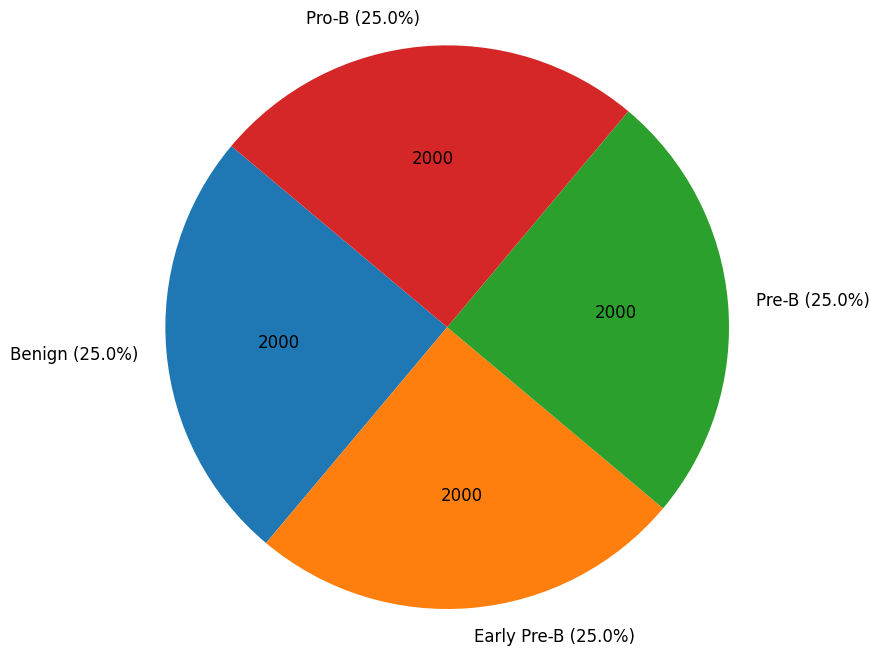

In [9]:
# Count occurrences in each DataFrame
train_counts = train_dataframe['Class'].value_counts()
val_counts = validation_dataframe['Class'].value_counts()
test_counts = test_dataframe['Class'].value_counts()

# Combine and sum the counts
total_counts = train_counts.add(val_counts, fill_value=0)
total_counts = total_counts.add(test_counts, fill_value=0)
total_counts = total_counts.sort_index()

# Prepare labels with percentages
total = total_counts.sum()
labels_with_percent = [f"{label} ({(count/total)*100:.1f}%)" for label, count in zip(total_counts.index, total_counts.values)]

# Define custom autopct function to show raw count
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}"
    return autopct

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_counts.values, labels=labels_with_percent, autopct=make_autopct(total_counts.values), startangle=140, textprops={'fontsize': 12})
plt.axis('equal')
plt.show()

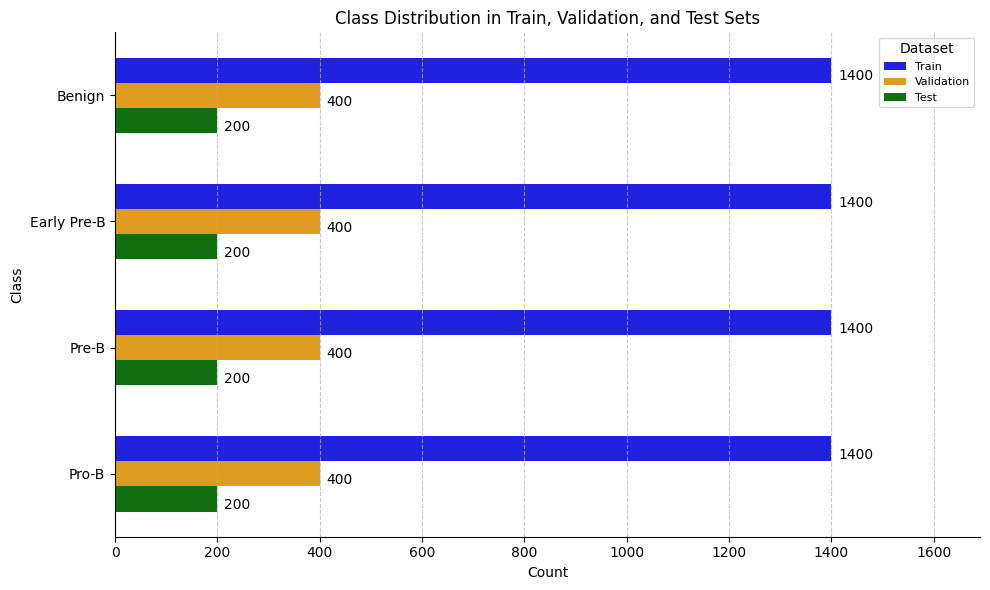

In [10]:
# Count occurrences of each class in train, validation, and test datasets
train_counts = train_dataframe['Class'].value_counts().sort_index()
val_counts = validation_dataframe['Class'].value_counts().sort_index()
test_counts = test_dataframe['Class'].value_counts().sort_index()

# Combine into a DataFrame with the index kept as a column
data_counts = pd.DataFrame({
    'Class': train_counts.index,
    'Train': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values
}).melt(id_vars='Class', var_name='Dataset', value_name='Count')

# Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(y='Class', x='Count', hue='Dataset', data=data_counts, 
                 palette=['blue', 'orange', 'green'], orient='h', width=0.6)

# Add count labels to the right of the bars with slight downward offset
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.0 + 0.05),  # pushed slightly down
                ha='left', va='center', 
                fontsize=10, color='black', 
                xytext=(5, 0), textcoords='offset points')

# Remove borders (spines)
sns.despine(top=True, right=True, left=False, bottom=False)

# Dynamically set the x-axis limits with some extra space on the right
left, right = ax.get_xlim()  # Get current x-limits

# Set the new right limit with a 15% increase
right += (right - left) * 0.15  # Increase right by 15%

# Apply the new limits to the x-axis
ax.set_xlim(left, right)

# Add labels and title
plt.ylabel("Class")
plt.xlabel("Count")
plt.title("Class Distribution in Train, Validation, and Test Sets")

# Move the legend
plt.legend(title="Dataset", loc='upper right', fontsize=8)

# Add grid only along x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tidy layout
plt.tight_layout()
plt.show()

In [11]:
def preprocess_image(image):
    """
    Simple Min-Max Normalization for RGB image.
    Safe for Keras ImageDataGenerator (expects one image at a time).
    Returns float32 image scaled to [0, 1].
    """
    image = image.astype(np.float32)

    min_val = image.min()
    max_val = image.max()

    # avoid division by zero
    if max_val - min_val < 1e-6:
        return np.zeros_like(image, dtype=np.float32)

    # min-max scale to [0, 1]
    image = (image - min_val) / (max_val - min_val)

    return image


In [12]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image     
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)


train_data = train_datagen.flow_from_dataframe(train_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, seed=42)

validation_data = val_datagen.flow_from_dataframe(validation_dataframe, x_col='Class Path',
                                     y_col='Class', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE, seed=42)

test_data = test_datagen.flow_from_dataframe(test_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, shuffle=False, seed=42)

Found 5600 validated image filenames belonging to 4 classes.
Found 1600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [13]:
def _denormalize_for_display(img):
    """
    Convert a preprocessed float image to uint8 for plt.imshow.
    Uses per-image min-max scaling so display is robust.
    """
    im = img.copy().astype(np.float32)
    im_min = float(np.min(im))
    im_max = float(np.max(im))
    if im_max - im_min < 1e-6:
        return np.zeros_like(im, dtype=np.uint8)
    im_out = (im - im_min) / (im_max - im_min)
    im_out = (im_out * 255.0).clip(0, 255).astype(np.uint8)
    return im_out


def show_from_generator(generator, n=5):
    """
    Fetch one batch from a Keras ImageDataGenerator (or Sequence) and show `n` images.
    - Make sure the generator was created AFTER you updated preprocess_image.
    """
    # Get a batch robustly
    try:
        batch = next(generator)
    except TypeError:
        batch = generator[0]
    except StopIteration:
        gen_iter = iter(generator)
        batch = next(gen_iter)

    # handle common batch formats
    if isinstance(batch, (tuple, list)):
        images, labels = batch[0], batch[1] if len(batch) > 1 else None
    elif isinstance(batch, dict):
        images = batch.get("images") or batch.get("x") or batch.get("inputs")
        labels = batch.get("labels") or batch.get("y")
    else:
        raise ValueError("Unsupported batch format from generator")

    images = np.asarray(images)
    n = min(n, len(images))
    plt.figure(figsize=(3 * n, 3))
    for i in range(n):
        img = images[i]
        disp = _denormalize_for_display(img)
        plt.subplot(1, n, i + 1)
        plt.imshow(disp)
        if labels is not None:
            lbl = np.argmax(labels[i]) if getattr(labels, "ndim", 0) > 1 else labels[i]
            plt.title(f"Label: {lbl}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

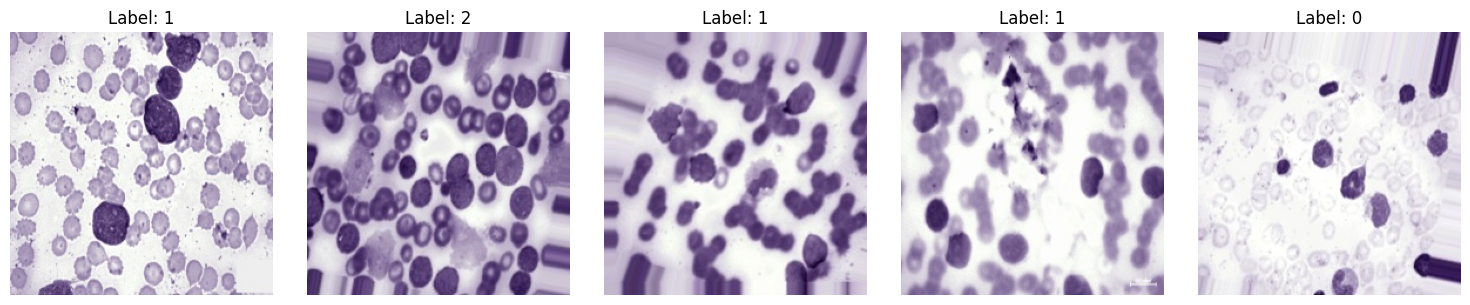

In [14]:
show_from_generator(train_data)

In [15]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="F1Score")
class F1Score(tf.keras.metrics.Metric):
    """
    Custom Keras metric to compute the F1 Score.
    The F1 score is the harmonic mean of precision and recall.
    """

    def __init__(self, name='f1_score', **kwargs):
        """
        Initializes the F1Score metric. 
        - Uses Keras' Precision and Recall metrics as intermediate steps.
        """
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()  # Precision metric
        self.recall = tf.keras.metrics.Recall()  # Recall metric

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        Updates the state of the metric.
        - This method is called during training to update precision and recall.
        - The precision and recall states are updated based on true and predicted values.
        """
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        """
        Computes and returns the F1 score.
        - F1 score is calculated as the harmonic mean of precision and recall.
        - Prevents division by zero by adding a small epsilon value to the denominator.
        """
        p = self.precision.result()  # Get precision value
        r = self.recall.result()  # Get recall value
        return 2 * (p * r) / (p + r + tf.keras.backend.epsilon())  # Calculate F1 score

    def reset_states(self):
        """
        Resets the states of the precision and recall metrics.
        - This is called at the beginning of each epoch.
        """
        self.precision.reset_states()  # Reset precision state
        self.recall.reset_states()  # Reset recall state


In [16]:
class RestoreBestValidationModel(Callback):
    """
    Custom Keras Callback to restore model weights from the best epoch based on validation accuracy.
    - Tracks the best validation accuracy during training.
    - Restores the model weights from the epoch with the best validation accuracy when training finishes.
    """
    
    def __init__(self):
        super(RestoreBestValidationModel, self).__init__()
        # Initialize best validation accuracy, epoch, and weights to track the best model
        self.best_val_acc = -1
        self.best_epoch = -1
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        """
        Callback function executed at the end of each epoch.
        - Compares the current validation accuracy with the best validation accuracy.
        - If the current validation accuracy is higher or tied but at a later epoch, updates the best model weights.
        """
        # Get validation accuracy from logs
        val_acc = logs.get('val_accuracy')
        
        if val_acc is not None:
            # Update the best validation accuracy and weights if the current one is better or at a later epoch
            if val_acc > self.best_val_acc or (val_acc == self.best_val_acc and epoch > self.best_epoch):
                self.best_val_acc = val_acc
                self.best_epoch = epoch
                self.best_weights = self.model.get_weights()  # Store the model's weights
                print(f"\nModel weights updated at epoch {epoch + 1} with val_accuracy: {val_acc:.4f}")

    def on_train_end(self, logs=None):
        """
        Callback function executed at the end of training.
        - Restores the model weights from the epoch with the best validation accuracy.
        """
        # If we found a better model during training, restore the best weights
        if self.best_weights is not None:
            print(f"\nRestoring model weights from best epoch {self.best_epoch + 1} with val_accuracy: {self.best_val_acc:.4f}")
            self.model.set_weights(self.best_weights)  # Set the weights back to the best model's weights

# Instantiate the callback
restore_best = RestoreBestValidationModel()


In [17]:
model_name = "DenseNet121"
base_model = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet',
                                            input_shape=img_shape, pooling=None)

base_model.trainable = False 

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(64, activation='relu')(x)
x = Dense(len(labels), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

model.compile(Adamax(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy', 
                        Precision(name='precision'), 
                        Recall(name='recall'),
                        F1Score(),
                        AUC(name='auc')])
model.summary()

I0000 00:00:1764242212.214866      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,103,364 (27.10 MB)

 Trainable params: 65,860 (257.27 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [18]:
history = model.fit(
    train_data,
    epochs=EPOCH,
    validation_data=validation_data,
    callbacks=[restore_best],
    shuffle=True  
)

Epoch 1/30


I0000 00:00:1764242229.339837      68 service.cc:148] XLA service 0x7aa930004360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764242229.340609      68 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764242232.071739      68 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/175 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.3359 - auc: 0.6274 - f1_score: 0.3370 - loss: 1.5776 - precision: 0.3735 - recall: 0.3125   

I0000 00:00:1764242242.312140      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7240 - auc: 0.8907 - f1_score: 0.6027 - loss: 0.8302 - precision: 0.8660 - recall: 0.4774
Model weights updated at epoch 1 with val_accuracy: 0.9081
175/175 ━━━━━━━━━━━━━━━━━━━━ 75s 282ms/step - accuracy: 0.7246 - auc: 0.8911 - f1_score: 0.6037 - loss: 0.8288 - precision: 0.8663 - recall: 0.4785 - val_accuracy: 0.9081 - val_auc: 0.9865 - val_f1_score: 0.8994 - val_loss: 0.3480 - val_precision: 0.9419 - val_recall: 0.8606
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9162 - auc: 0.9894 - f1_score: 0.9143 - loss: 0.3061 - precision: 0.9504 - recall: 0.8808
Model weights updated at epoch 2 with val_accuracy: 0.9162
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - accuracy: 0.9162 - auc: 0.9894 - f1_score: 0.9143 - loss: 0.3060 - precision: 0.9504 - recall: 0.8809 - val_accuracy: 0.9162 - val_auc: 0.9878 - val_f1_score: 0.9101 - val_loss: 0.2727 - val_precision: 0.9285 - val_recall: 0.8925
Epoch 3/30
175/175 ━━━━━━━

In [19]:
model.save(f"{model_name}.keras") 

In [20]:
#model = load_model(f"{model_name}.keras")  

In [21]:
# Save history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [22]:
# Load history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)

In [23]:
epochs = range(1, len(history['loss']) + 1)

# Training and validation metrics
tr_loss = history['loss']
val_loss = history['val_loss']
tr_acc = history['accuracy']
val_acc = history['val_accuracy']
tr_precision = history['precision']
val_precision = history['val_precision']
tr_auc = history['auc']
val_auc = history['val_auc']
tr_f1 = history['f1_score']
val_f1 = history['val_f1_score']

In [24]:
def print_best_metrics(metric_name, train, val):
    best_epoch = np.argmax(val) + 1
    print(f"📌 Best {metric_name} at epoch {best_epoch}:")
    print(f"   - Train {metric_name}: {abs(train[best_epoch - 1]):.4f}")
    print(f"   - Val {metric_name}:   {abs(val[best_epoch - 1]):.4f}\n")

print_best_metrics("Accuracy", tr_acc, val_acc)
print_best_metrics("Precision", tr_precision, val_precision)
print_best_metrics("AUC", tr_auc, val_auc)
print_best_metrics("F1 Score", tr_f1, val_f1)
print_best_metrics("Loss", [-x for x in tr_loss], [-x for x in val_loss])  # inverted for max-based search

📌 Best Accuracy at epoch 26:
   - Train Accuracy: 0.9875
   - Val Accuracy:   0.9688

📌 Best Precision at epoch 30:
   - Train Precision: 0.9927
   - Val Precision:   0.9718

📌 Best AUC at epoch 24:
   - Train AUC: 0.9996
   - Val AUC:   0.9974

📌 Best F1 Score at epoch 30:
   - Train F1 Score: 0.9913
   - Val F1 Score:   0.9696

📌 Best Loss at epoch 30:
   - Train Loss: 0.0386
   - Val Loss:   0.1018



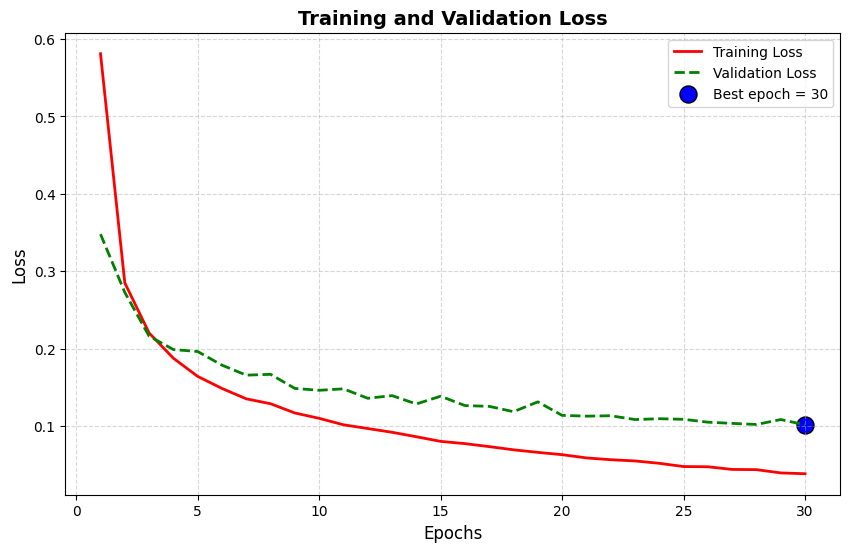

In [25]:
best_epoch_loss = np.argmin(val_loss)
best_val_loss = val_loss[best_epoch_loss]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_loss, color='red', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, color='green', label='Validation Loss', linestyle='--', linewidth=2)
plt.scatter(best_epoch_loss + 1, best_val_loss, s=150, c='blue',
            label=f'Best epoch = {best_epoch_loss + 1}', edgecolors='black')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

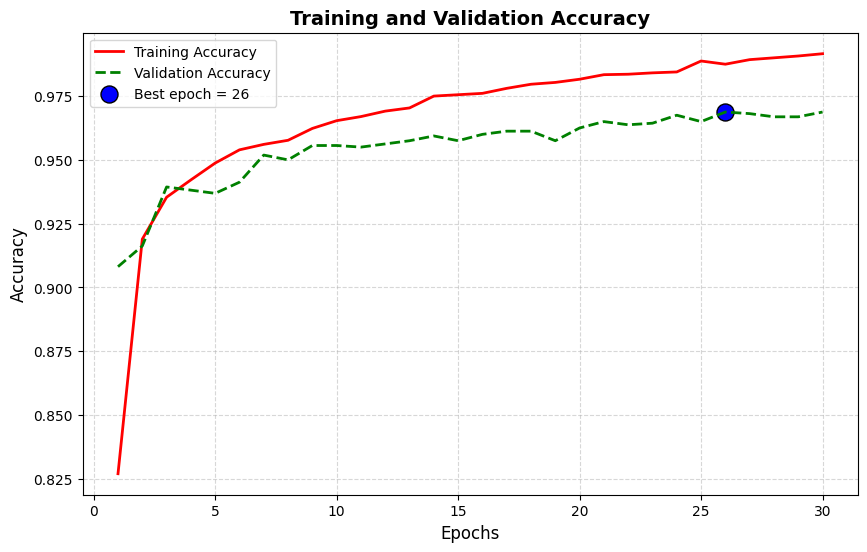

In [26]:
best_epoch_acc = np.argmax(val_acc)
best_val_acc = val_acc[best_epoch_acc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_acc, color='red', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, color='green', label='Validation Accuracy', linestyle='--', linewidth=2)
plt.scatter(best_epoch_acc + 1, best_val_acc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_acc + 1}', edgecolors='black')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


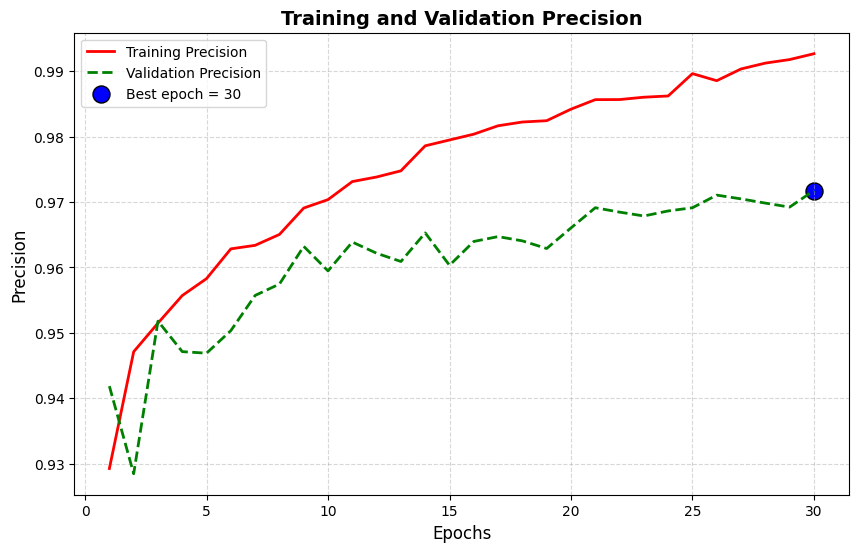

In [27]:
best_epoch_prec = np.argmax(val_precision)
best_val_prec = val_precision[best_epoch_prec]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_precision, color='red', label='Training Precision', linewidth=2)
plt.plot(epochs, val_precision, color='green', label='Validation Precision', linestyle='--', linewidth=2)
plt.scatter(best_epoch_prec + 1, best_val_prec, s=150, c='blue',
            label=f'Best epoch = {best_epoch_prec + 1}', edgecolors='black')
plt.title('Training and Validation Precision', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


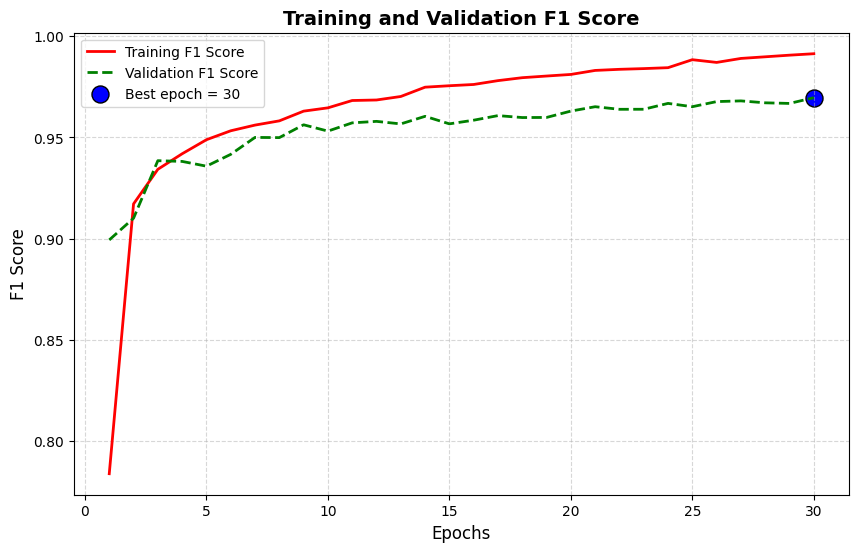

In [28]:
best_epoch_f1 = np.argmax(val_f1)
best_val_f1 = val_f1[best_epoch_f1]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_f1, color='red', label='Training F1 Score', linewidth=2)
plt.plot(epochs, val_f1, color='green', label='Validation F1 Score', linestyle='--', linewidth=2)
plt.scatter(best_epoch_f1 + 1, best_val_f1, s=150, c='blue',
            label=f'Best epoch = {best_epoch_f1 + 1}', edgecolors='black')
plt.title('Training and Validation F1 Score', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

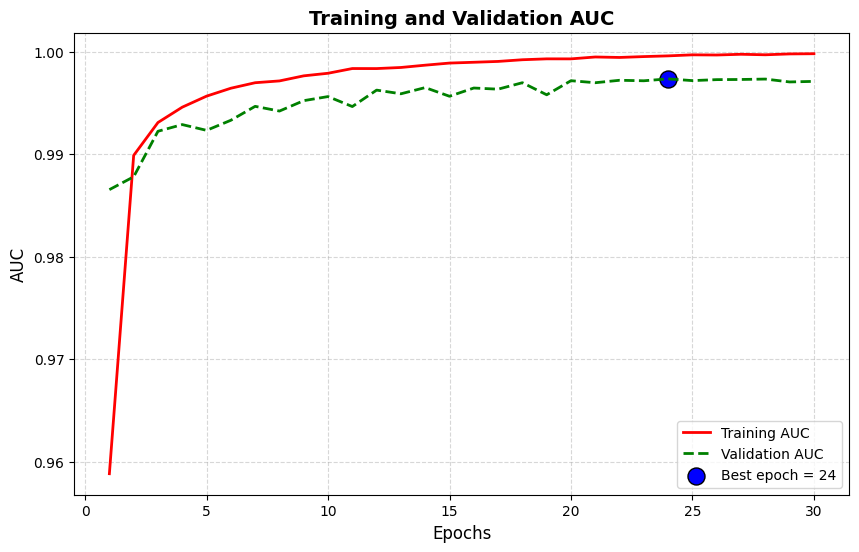

In [29]:
best_epoch_auc = np.argmax(val_auc)
best_val_auc = val_auc[best_epoch_auc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_auc, color='red', label='Training AUC', linewidth=2)
plt.plot(epochs, val_auc, color='green', label='Validation AUC', linestyle='--', linewidth=2)
plt.scatter(best_epoch_auc + 1, best_val_auc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_auc + 1}', edgecolors='black')
plt.title('Training and Validation AUC', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

In [30]:
def evaluate_model(model, test_data, labels, model_name, test_dataframe, batch_size=BATCH_SIZE):
    """
    Evaluate a trained Keras model using a test data generator.

    Args:
        model (Model): Trained Keras model.
        test_data (Iterator): A Keras data generator for testing.
        labels (List[str]): Class label names.
        model_name (str): Name of the model (for display).
        test_dataframe (pd.DataFrame): DataFrame with test samples (for step calculation).
        batch_size (int): Batch size used in the test_data generator.

    Returns:
        Tuple[dict, dict]: 
            - Dictionary containing accuracy, precision, recall, F1 score, and AUC.
            - Dictionary of AUC curve data {class_label: (fpr, tpr)} for ROC plotting.
    """

    # Calculate steps needed for full evaluation
    steps = math.ceil(len(test_dataframe) / batch_size)

    y_true = []
    y_pred = []
    y_probs = []

    # Loop through batches and collect predictions and true labels
    for _ in tqdm(range(steps), desc=f"Evaluating {model_name}"):
        images, labels_batch = next(test_data)

        preds = model.predict(images, verbose=0)            # Predicted probabilities
        y_probs.extend(preds)                               # Save for AUC

        y_pred.extend(np.argmax(preds, axis=-1))            # Predicted class indices
        y_true.extend(np.argmax(labels_batch, axis=-1))     # True class indices

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    # Calculate performance metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    try:
        auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')
    except ValueError:
        auc = float('nan')

    # Generate classification report
    report = classification_report(y_true, y_pred, target_names=labels)

    # Print summary metrics
    print(f"--- {model_name} ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}\n")
    print("Classification Report:\n")
    print(report)

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        annot_kws={'size': 14}, cbar=True, linewidths=0.5, linecolor='gray',
        cbar_kws={'shrink': 0.8}
    )
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12, rotation=45 if len(labels) > 10 else 0)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Compute ROC curve data per class
    auc_curve_data = {}
    try:
        for i, label in enumerate(labels):
            fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
            auc_curve_data[label] = (fpr, tpr)
    except Exception:
        auc_curve_data = {}

    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc
    }, auc_curve_data


Evaluating DenseNet121: 100%|██████████| 25/25 [00:17<00:00,  1.46it/s]


--- DenseNet121 ---
Accuracy : 0.9637
Precision: 0.9637
Recall   : 0.9637
F1 Score : 0.9637
AUC      : 0.9977

Classification Report:

              precision    recall  f1-score   support

      Benign       0.94      0.95      0.95       200
 Early Pre-B       0.94      0.93      0.94       200
       Pre-B       0.99      0.98      0.99       200
       Pro-B       0.98      0.99      0.99       200

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



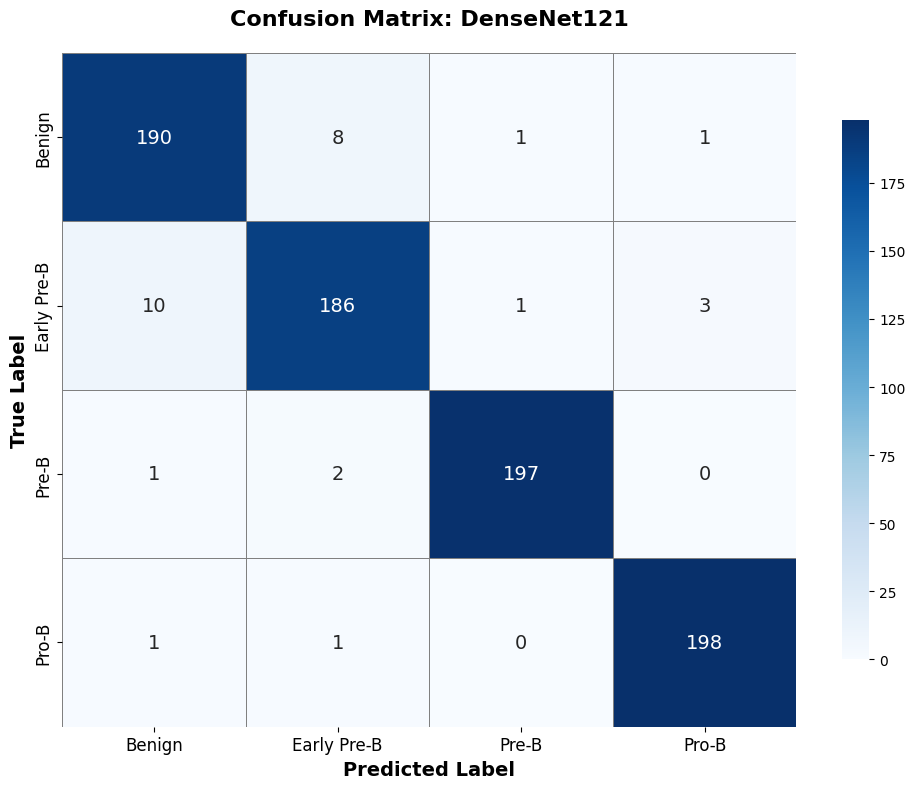

In [31]:
results, auc_curve_data = evaluate_model(model, test_data, labels, model_name, test_dataframe)

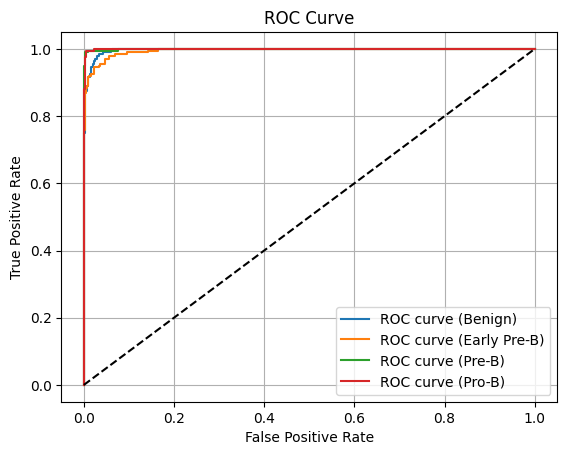

In [32]:
# Plotting the ROC curve
for label, (fpr, tpr) in auc_curve_data.items():
    plt.plot(fpr, tpr, label=f'ROC curve ({label})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

----------------
Bootstrap 95% Confidence interval


In [33]:
# -----------------------------
# Parameters
# -----------------------------
B = 1000                # number of bootstrap samples
RNG_SEED = 42

# 1) Get predictions and true labels
probs = model.predict(test_data, verbose=1)      # shape (N, num_classes)
y_true = np.asarray(test_data.classes)           # integer labels shape (N,)
num_classes = probs.shape[1]
y_pred = np.argmax(probs, axis=1)

# Point estimates
point_accuracy = accuracy_score(y_true, y_pred)
point_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
point_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
point_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
try:
    y_true_onehot = np.eye(num_classes)[y_true]
    point_auc = roc_auc_score(y_true_onehot, probs, multi_class='ovr', average='macro')
except Exception:
    point_auc = np.nan

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step


In [34]:
# 2) Bootstrap
rng = np.random.RandomState(RNG_SEED)
metrics_boot = {k: [] for k in ["accuracy", "precision", "recall", "f1", "auc"]}
N = len(y_true)

for i in tqdm(range(B), desc="Bootstrap samples"):
    idx = rng.randint(0, N, size=N)   # sample with replacement
    y_true_b, y_pred_b, probs_b = y_true[idx], y_pred[idx], probs[idx]

    metrics_boot["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    metrics_boot["precision"].append(precision_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["recall"].append(recall_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["f1"].append(f1_score(y_true_b, y_pred_b, average='macro', zero_division=0))

    try:
        y_true_b_onehot = np.eye(num_classes)[y_true_b]
        auc_b = roc_auc_score(y_true_b_onehot, probs_b, multi_class='ovr', average='macro')
    except Exception:
        auc_b = np.nan
    metrics_boot["auc"].append(auc_b)

# Convert lists to arrays
for k in metrics_boot:
    metrics_boot[k] = np.array(metrics_boot[k], dtype=np.float32)

Bootstrap samples: 100%|██████████| 1000/1000 [00:05<00:00, 167.25it/s]


In [35]:
# 3) Compute 95% CI
def ci95(arr):
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return (np.nan, np.nan)
    return np.percentile(arr, [2.5, 97.5])

results = []
for name, point in [
    ("accuracy", point_accuracy),
    ("precision", point_precision),
    ("recall", point_recall),
    ("f1", point_f1),
    ("auc", point_auc)
]:
    lo, hi = ci95(metrics_boot[name])
    results.append({
        "metric": name,
        "point_estimate": point,
        "ci_lower": lo,
        "ci_upper": hi,
        "n_boot_valid": int(np.sum(~np.isnan(metrics_boot[name])))
    })

df_results = pd.DataFrame(results).set_index("metric")
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results)

           point_estimate  ci_lower  ci_upper  n_boot_valid
metric                                                     
accuracy           0.9637    0.9500    0.9775          1000
precision          0.9637    0.9498    0.9772          1000
recall             0.9637    0.9499    0.9771          1000
f1                 0.9637    0.9496    0.9772          1000
auc                0.9977    0.9963    0.9989          1000


In [36]:
def plot_bootstrap_metrics(metrics_boot, df_results, n_cols=3, figsize_per_plot=(5, 4),
                           w_pad=0.6, h_pad=1.5, shift_factor=0.5):
    """
    Plot bootstrap metric distributions.

    Args:
        metrics_boot: dict of metric -> bootstrap array
        df_results: DataFrame with point estimates and CIs
        n_cols: 
            >0 -> number of columns for grid layout
             0 -> plot each metric separately (one figure per metric)
        figsize_per_plot: (width, height) per subplot
        w_pad: horizontal gap between subplots (grid mode only)
        h_pad: vertical gap between subplots (grid mode only)
        shift_factor: how much to center last row if not full (grid mode only)
    """

    metrics = list(metrics_boot.keys())
    n_metrics = len(metrics)

    # --------------------
    # Single-plot mode
    # --------------------
    if n_cols == 0:
        for metric in metrics:
            vals = metrics_boot[metric]
            vals_nonan = vals[~np.isnan(vals)]

            fig, ax = plt.subplots(figsize=figsize_per_plot)
            ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
            ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
            ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
            ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

            ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
            ax.legend()
            plt.tight_layout()
            plt.show()
        return  # done

    # --------------------
    # Grid mode
    # --------------------
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_per_plot[0]*n_cols,
                                      figsize_per_plot[1]*n_rows))
    axes = np.array(axes).reshape(-1)  # flatten

    for i, metric in enumerate(metrics):
        ax = axes[i]
        vals = metrics_boot[metric]
        vals_nonan = vals[~np.isnan(vals)]

        ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
        ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
        ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
        ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

        ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
        ax.legend()

        # 🔹 Format x-axis ticks to 2 decimal places
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))

    # remove unused axes
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    # ---- Center last row if it's not full ----
    last_row_count = n_metrics % n_cols
    if last_row_count != 0:
        empty_slots = n_cols - last_row_count
        last_row_axes = axes[n_cols*(n_rows-1):n_cols*(n_rows-1)+last_row_count]

        for ax in last_row_axes:
            pos = ax.get_position()
            shift = (empty_slots / n_cols) * shift_factor
            pos_new = [pos.x0 + shift, pos.y0, pos.width, pos.height]
            ax.set_position(pos_new)

    plt.tight_layout(pad=1.0, w_pad=w_pad, h_pad=h_pad)
    plt.show()

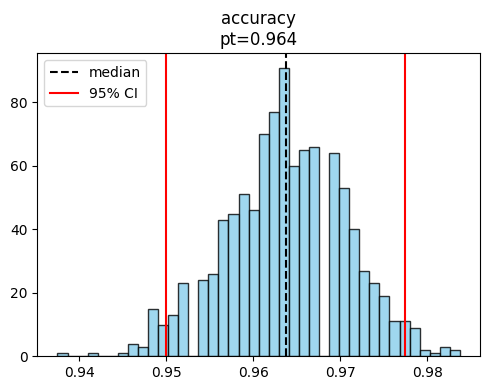

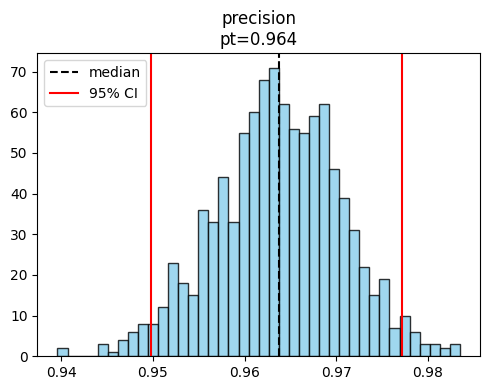

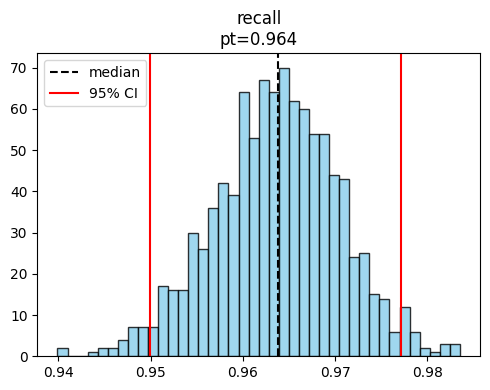

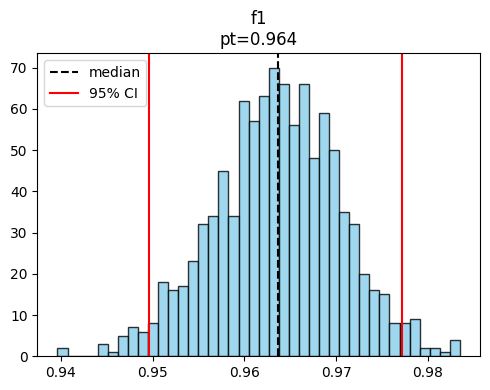

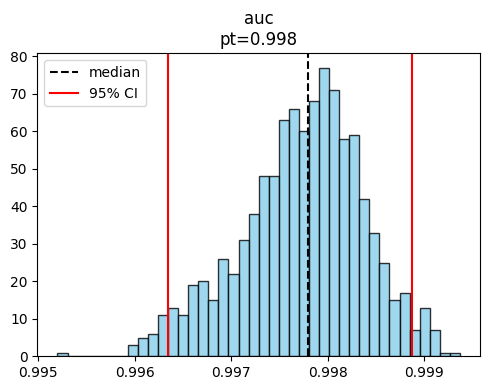

In [37]:
plot_bootstrap_metrics(
    metrics_boot, 
    df_results, 
    n_cols=0,        # number of columns in grid (set 0 for separate plots, 2 or 3 for grid)
    w_pad=0.5,       # horizontal space between columns (increase -> wider gap)
    h_pad=1.0,       # vertical space between rows (increase -> taller gap)
    shift_factor=0.0 # how much to horizontally shift last-row plots for centering
)
